# 01 · Datos: taxonomía, textos sintéticos, imágenes, voz y canal telefónico

No existe un dataset público en español de estafas multimodales con etiquetas de **táctica**, y no podemos
usar llamadas reales de clientes (RGPD). Por eso construimos nuestros propios datos, de forma
**reproducible** y documentada, y los complementamos con datasets abiertos de Hugging Face:

| Dataset | Modalidad | Origen | Uso |
|---|---|---|---|
| `textos_sinteticos.csv` | Texto (es) | Generado por nosotros con Qwen3 8B (local) | Entrenar TacticNet |
| `ucirvine/sms_spam` | Texto (en) | Hugging Face | Señal binaria adicional (spam/no spam) |
| `test_manual.csv` | Texto (es) | Escrito a mano por nosotros | **Test** de generalización fuera de lo sintético |
| `campaigns.json` + imágenes | Texto + imagen | Redactado por nosotros, renderizado con Pillow | Base de campañas conocidas |
| Demo (`data/demo/`) | Imagen + audio | Pillow y Bark | Los 5 casos de la demo |
| `facebook/multilingual_librispeech` (es) | Audio | Hugging Face | Voz humana real para VozSinteticaNet |
| Clips de Bark y MMS-TTS | Audio | Generados por nosotros | Voz sintética para VozSinteticaNet |

El código vive en `src/diputado/data/` y este notebook lo ejecuta, lo inspecciona y justifica cada decisión.
Las etapas costosas (generación con LLM y con Bark) se guardan en caché: si el fichero ya existe no se repiten.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Audio, Markdown, display
from PIL import Image

from diputado import config

config.ensure_dirs()
config.ensure_ffmpeg_on_path()
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
pd.set_option("display.max_colwidth", 120)

## 1. Taxonomía de tácticas

Un detector binario («estafa sí/no») no basta para explicar el veredicto a una persona mayor. Por eso
definimos **7 tácticas** de manipulación, inspiradas en las campañas que publican el INCIBE (línea 017),
la Policía Nacional y los propios bancos. Son multietiqueta: un mismo mensaje suele combinar varias.

In [2]:
tax = pd.DataFrame([{"Táctica": config.TACTIC_LABELS[k], "Clave": k, "Descripción": v} for k, v in config.TACTICS.items()])
display(tax.style.hide(axis="index"))

Táctica,Clave,Descripción
Suplantación de entidad,suplantacion_entidad,"Se hace pasar por un banco, Correos, la DGT, Hacienda u otra entidad"
Urgencia o amenaza,urgencia_amenaza,"Mete prisa o amenaza con bloqueos, multas o pérdidas"
Pide claves o códigos,credenciales_otp,"Pide claves, PIN, códigos SMS o datos de la tarjeta"
Enlace sospechoso,enlace_sospechoso,Empuja a pulsar un enlace o descargar una app
Pide dinero,pago_transferencia,"Pide un pago, una transferencia o un Bizum"
Falso familiar,falso_familiar,Finge ser un familiar con un número nuevo o en apuros
Premio o inversión milagro,premio_inversion,"Promete premios, herencias o inversiones con rentabilidad milagrosa"


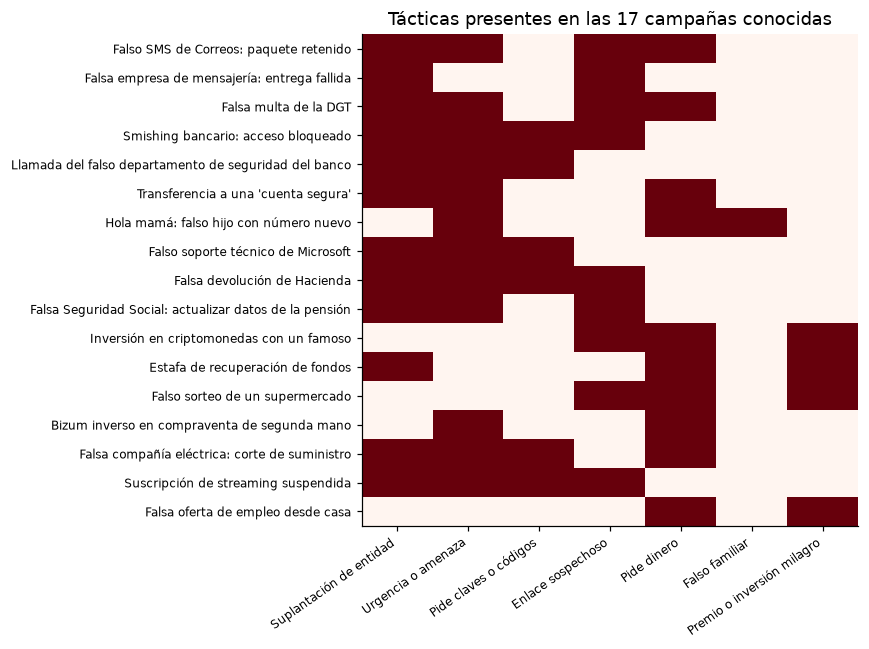

In [3]:
from diputado.core import campaigns

camps = campaigns.load()
mat = pd.DataFrame([{t: int(t in c["tacticas"]) for t in config.TACTICS} for c in camps], index=[c["nombre"] for c in camps])
fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(mat.values, cmap="Reds", aspect="auto")
ax.set_xticks(range(len(mat.columns)), [config.TACTIC_LABELS[t] for t in mat.columns], rotation=35, ha="right", fontsize=8)
ax.set_yticks(range(len(mat)), mat.index, fontsize=8)
ax.set_title(f"Tácticas presentes en las {len(camps)} campañas conocidas")
plt.tight_layout()

## 2. Textos sintéticos con Qwen3 (supervisión débil por receta)

**Método.** Definimos 20 *recetas* de estafa y 15 de mensajes legítimos. Cada receta fija un canal
(SMS, WhatsApp, email, transcripción de llamada, web o carta), un escenario y sus etiquetas de táctica.
Pedimos a `qwen3:8b` (en local, mediante Ollama, con salida JSON validada por esquema) 8 variantes por
llamada con temperatura 0,95 y semillas distintas. Las etiquetas se **heredan de la receta**
(supervisión débil): no dependemos de que el LLM etiquete bien, solo de que escriba bien.

**Decisiones clave:**

* **Negativos difíciles.** Muchas recetas legítimas hablan de bancos, códigos OTP o paquetes. Sin ellas,
  el modelo aprendería que «banco» o «código» implican estafa, y marcaría en rojo el SMS legítimo de la demo.
* **Nombres inventados** («BancoSur», «EnvíaYa») para no asociar marcas reales con fraude.
* **Deduplicación** por hash del texto normalizado.
* La generación es **reanudable**: si se interrumpe, continúa donde se quedó.

In [4]:
from diputado.data import synth_text

recetas = pd.DataFrame(
    [{"id": f"S{i}", "tipo": "estafa", "canal": c, "escenario": e, "tácticas": ", ".join(config.TACTIC_LABELS[t] for t in tac)}
     for i, (c, e, tac) in enumerate(synth_text.SCAM_RECIPES)]
    + [{"id": f"L{i}", "tipo": "legítimo", "canal": c, "escenario": e, "tácticas": ""} for i, (c, e) in enumerate(synth_text.LEGIT_RECIPES)])
display(recetas.head(8))
print(f"{len(synth_text.SCAM_RECIPES)} recetas de estafa y {len(synth_text.LEGIT_RECIPES)} legítimas")
print("Ejemplo de prompt:\n")
print(synth_text.PROMPT.format(n=8, tipo="mensajes fraudulentos usados por estafadores", canal="sms",
                               escenario=synth_text.SCAM_RECIPES[0][1], extra="…"))

,id,tipo,canal,escenario,tácticas
0,S0,estafa,sms,Correos o una empresa de paquetería retiene un paquete por tasas pequeñas y da un enlace para pagar,"Suplantación de entidad, Urgencia o amenaza, Enlace sospechoso, Pide dinero"
1,S1,estafa,sms,Una empresa de mensajería dice que no pudo entregar y pide reprogramar en un enlace acortado,"Suplantación de entidad, Enlace sospechoso"
2,S2,estafa,sms,La DGT avisa de una multa pendiente con recargo si no se paga en un enlace,"Suplantación de entidad, Urgencia o amenaza, Enlace sospechoso, Pide dinero"
3,S3,estafa,sms,El banco avisa de un acceso no autorizado y pide verificar la identidad en un enlace en 24 horas,"Suplantación de entidad, Urgencia o amenaza, Enlace sospechoso, Pide claves o códigos"
4,S4,estafa,sms,El banco dice que se ha bloqueado la tarjeta y hay que llamar a un número o entrar en una web,"Suplantación de entidad, Urgencia o amenaza, Enlace sospechoso"
5,S5,estafa,llamada,Transcripción de una llamada de un falso empleado de seguridad del banco que pide el código SMS para anular un cargo,"Suplantación de entidad, Urgencia o amenaza, Pide claves o códigos"
6,S6,estafa,llamada,Transcripción de una llamada que pide transferir los ahorros a una cuenta segura porque la cuenta está hackeada,"Suplantación de entidad, Urgencia o amenaza, Pide dinero"
7,S7,estafa,llamada,Transcripción de un falso técnico informático que pide instalar AnyDesk y las claves del banco,"Suplantación de entidad, Urgencia o amenaza, Pide claves o códigos"


20 recetas de estafa y 15 legítimas
Ejemplo de prompt:

Genera 8 ejemplos realistas y MUY distintos entre sí de mensajes fraudulentos usados por estafadores en español de España.
Canal: sms. Escenario: Correos o una empresa de paquetería retiene un paquete por tasas pequeñas y da un enlace para pagar.
Varía la longitud (de 1 a 5 frases), el tono, los importes, los nombres de empresas (usa nombres genéricos o inventados como "BancoSur", "Caja Levante", "EnvíaYa"), los dominios web y los números.
…
Escribe solo el texto del mensaje o la transcripción, sin comillas ni explicaciones.


In [5]:
CSV = config.SYNTHETIC_DIR / "textos_sinteticos.csv"
# Ya generado: la llamada solo deduplica y devuelve el dataset. Para regenerar desde cero, borrar el CSV
# (unos 45 minutos con una RTX 4070).
from diputado.ai import ollama_server

if ollama_server.is_up():
    synth = synth_text.generate(CSV, calls_per_scam=3, calls_per_legit=4)
else:
    synth = pd.read_csv(CSV)
print(f"{len(synth)} mensajes únicos · {synth['estafa'].mean():.0%} estafas")
display(synth.groupby(["canal", "estafa"]).size().unstack(fill_value=0).rename(columns={0: "legítimo", 1: "estafa"}))

1032 mensajes únicos · 53% estafas


estafa,legítimo,estafa
canal,,
carta,0,26
email,96,72
llamada,96,120
sms,194,185
web,0,26
whatsapp,95,122


In [6]:
for canal in ["sms", "whatsapp", "llamada", "email"]:
    sub = synth[synth["canal"] == canal]
    for lab in (1, 0):
        ex = sub[sub["estafa"] == lab].sample(1, random_state=3)["texto"].iloc[0]
        display(Markdown(f"**{canal} · {'estafa' if lab else 'legítimo'}:** {ex}"))

**sms · estafa:** ¡Urgente! Tu envío de Caja Levante está bloqueado. Debes abonar 30€ de tarifas antes de que se pierda. Paga aquí: [link].

**sms · legítimo:** Confirma tu compra de 35€ en EnvíaYa. Código: 7X9P2R. No lo compartas con nadie.

**whatsapp · estafa:** Mi tía Lorena necesita urgentemente el código que le envió el BancoSur para un traspaso. ¿Me lo pasas por favor? Es muy importante.

**whatsapp · legítimo:** Hace unos días recibí un correo de un dominio que imitaba a una empresa de telecomunicaciones. Me avisaron de un descuento si confirmaba algo. No me lo creí.

**llamada · estafa:** ¡Atención! Le estamos llamando porque su factura de la luz no ha sido pagada y si no lo hace ahora con tarjeta, le cortamos el suministro. Pague en el siguiente portal: luz-24h.net. ¡No deje que le corten la luz!

**llamada · legítimo:** Estoy frente a su casa con un paquete para entregarse, ¿puede abrir la puerta?

**email · estafa:** Señor/a [Nombre], su tarjeta de crédito asociada a [StreamingSur] no se aceptó. Puede ser debido a un error de datos. Actualice su información antes de las 24 horas. Link: streamingsur.com/actualizar

**email · legítimo:** Su compra con número 87654321 ha sido confirmada. La entrega se realizará en los próximos días mediante el servicio de EnvíaYa.

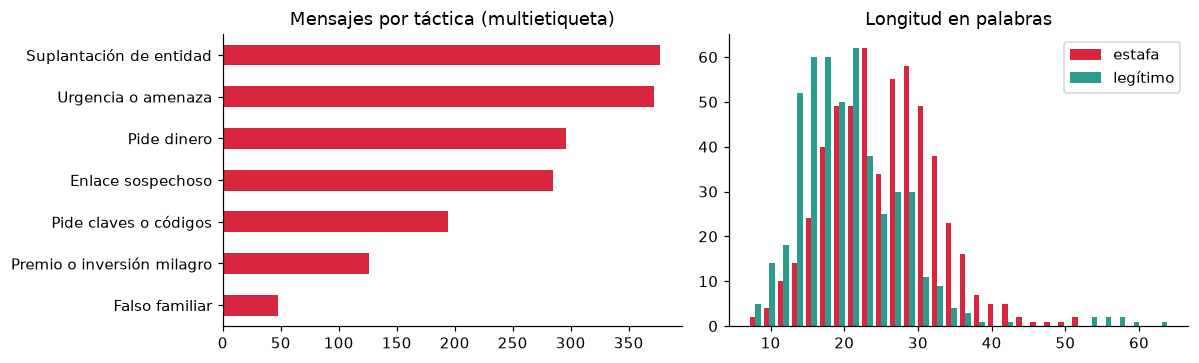

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
tac_counts = synth[list(config.TACTICS)].sum().rename(config.TACTIC_LABELS).sort_values()
tac_counts.plot.barh(ax=axes[0], color="#d7263d")
axes[0].set_title("Mensajes por táctica (multietiqueta)")
lens = synth["texto"].str.split().str.len()
axes[1].hist([lens[synth["estafa"] == 1], lens[synth["estafa"] == 0]], bins=30, label=["estafa", "legítimo"], color=["#d7263d", "#2a9d8f"])
axes[1].set_title("Longitud en palabras"); axes[1].legend()
plt.tight_layout()

### Controles de calidad

1. **Diversidad:** medimos la similitud coseno (embeddings e5) entre cada mensaje y su vecino más
   cercano. Si el LLM se repitiera, veríamos muchos pares por encima de 0,97.
2. **Fuga hacia el test manual:** comprobamos que ningún mensaje sintético sea casi idéntico a uno del
   test escrito a mano, para que la evaluación del notebook 02 sea honesta.
3. **Coherencia con las reglas:** los extractores deterministas deberían disparar mucho más en las
   estafas que en los legítimos. Es una comprobación barata de que las etiquetas heredadas tienen sentido.

C:\Users\jdmar\Desktop\Taller Multimodales\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Vecino más cercano dentro del sintético: mediana 0.947 · pares > 0.97: 120
Test manual vs sintético: similitud máxima media 0.909 · máximo 0.941


,mean,50%,75%
estafa,,,
legítimo,0.020686,0.00,0.0
estafa,0.215064,0.15,0.3


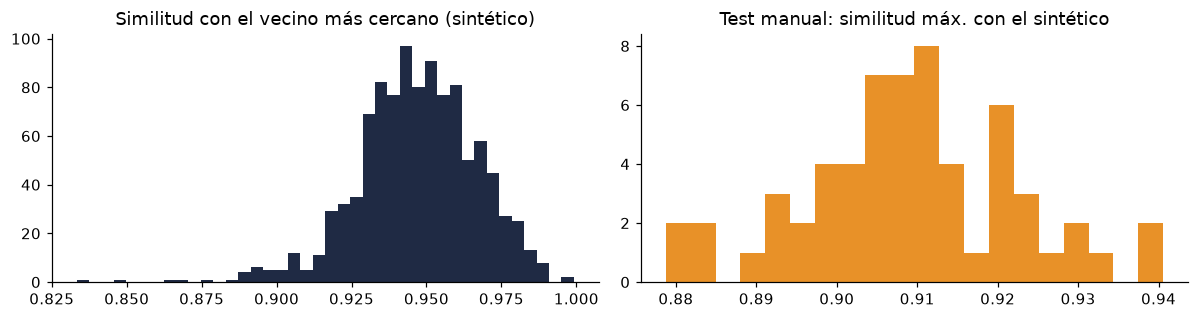

In [8]:
from diputado.ai import embeddings
from diputado.core import extractors

test = pd.read_csv(config.DATA_DIR / "test_manual.csv")
E = embeddings.embed_text(synth["texto"].tolist())
Et = embeddings.embed_text(test["texto"].tolist())
S = E @ E.T
np.fill_diagonal(S, -1)
nn = S.max(1)
leak = (Et @ E.T).max(1)
print(f"Vecino más cercano dentro del sintético: mediana {np.median(nn):.3f} · pares > 0.97: {(nn > 0.97).sum()}")
print(f"Test manual vs sintético: similitud máxima media {leak.mean():.3f} · máximo {leak.max():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 3))
axes[0].hist(nn, bins=40, color="#1f2a44"); axes[0].set_title("Similitud con el vecino más cercano (sintético)")
axes[1].hist(leak, bins=20, color="#e89128"); axes[1].set_title("Test manual: similitud máx. con el sintético")
plt.tight_layout()

flags = pd.DataFrame([extractors.extract(t)["red_flag_score"] for t in synth["texto"]], columns=["score"])
flags["estafa"] = synth["estafa"].values
display(flags.groupby("estafa")["score"].describe()[["mean", "50%", "75%"]].rename(index={0: "legítimo", 1: "estafa"}))

In [9]:
# Guardamos los embeddings para el notebook 02 (evita recalcularlos).
emb_dir = config.SYNTHETIC_DIR / "embeddings"
emb_dir.mkdir(exist_ok=True)
np.save(emb_dir / "synth_e5.npy", E.astype(np.float32))
np.save(emb_dir / "test_manual_e5.npy", Et.astype(np.float32))

## 3. UCI SMS Spam Collection

5.574 SMS en inglés etiquetados como *spam*/*ham*. No tiene etiquetas de táctica (las marcamos con -1 y
las **enmascaramos** en la pérdida del notebook 02), pero aporta variabilidad real de estilo. Como e5 es
multilingüe, lo que aprende sobre el inglés se transfiere parcialmente al español.

In [10]:
uci = synth_text.load_sms_spam()
print(f"{len(uci)} mensajes · {uci['estafa'].mean():.1%} spam")
display(uci[["texto", "estafa"]].sample(4, random_state=1))

5574 mensajes · 13.4% spam


,texto,estafa
1447,Looks like u wil b getting a headstart im leaving here bout 2.30ish but if u r desperate for my company I could head...,0
2032,"I noe la... U wana pei bf oso rite... K lor, other days den...",0
4432,2mro i am not coming to gym machan. Goodnight.,0
4888,Todays Vodafone numbers ending with 4882 are selected to a receive a £350 award. If your number matches call 0906401...,1


## 4. Test escrito a mano

Para no evaluarnos con datos que ha escrito el mismo modelo que genera el entrenamiento, redactamos
**a mano** 61 mensajes en español con sus etiquetas: estafas en canales variados y, sobre todo,
**negativos difíciles** (OTP legítimos con aviso de no compartir, avisos reales de paquetería, un hijo
pidiendo dinero desde su número habitual...). Es nuestro conjunto de test de referencia.

In [11]:
print(f"{len(test)} mensajes · {test['estafa'].sum()} estafas · {(1 - test['estafa']).sum()} legítimos")
display(test.sample(6, random_state=0)[["texto", "canal", "estafa"]])

60 mensajes · 36 estafas · 24 legítimos


,texto,canal,estafa
26,"Hola abuela, soy Pablo, tu nieto. He tenido un accidente con el coche y necesito dinero para el abogado. No se lo di...",llamada,1
35,Has ganado una tarjeta regalo de Mercadona de 300 euros por nuestro 50 aniversario! Responde la encuesta: mercadona-...,whatsapp,1
59,Su paquete de Correos esta disponible en la oficina de Calle Mayor 12. Tiene 15 dias para recogerlo con su DNI.,sms,0
28,Su certificado digital caduca hoy. Renuevelo urgentemente en sede-renovacion.online para no perder el acceso a sus t...,email,1
11,"Estimado cliente, su tarjeta ha sido bloqueada temporalmente por motivos de seguridad. Para reactivarla introduzca s...",email,1
2,"Hola papa, este es mi numero nuevo, el otro se me cayo al water jaja. Me puedes escribir por aqui?",whatsapp,1


## 5. Imágenes: campañas y casos de demo

Renderizamos las capturas con Pillow (`src/diputado/media/render.py`): burbujas de SMS y WhatsApp, correos,
webs y cartas. Ventajas frente a usar capturas reales: no contienen datos personales ni logotipos reales,
y podemos generar tantas variantes como necesitemos. El VLM (Qwen2.5-VL) las lee como si fueran
capturas reales del móvil.

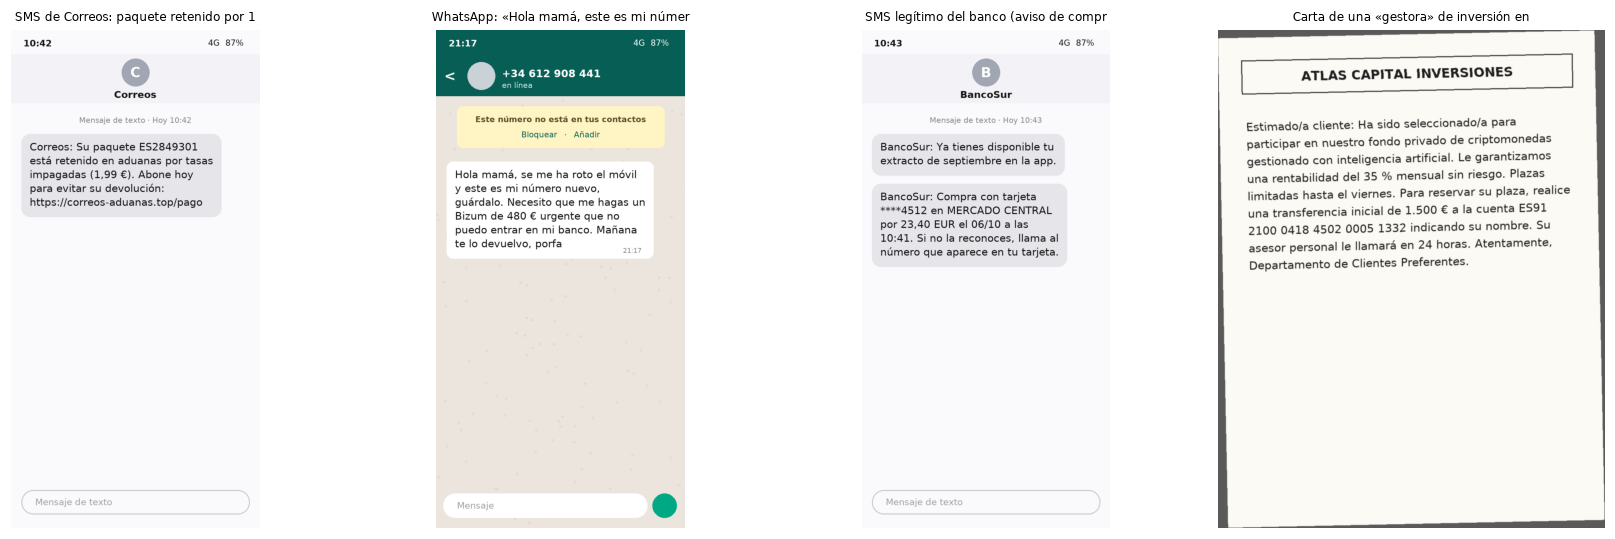

In [12]:
from diputado.data import demo_cases

demo_cases.build_images()
demo_cases.save_manifest()
cases = demo_cases.load()
imgs = [c for c in cases if c.get("imagen")]
fig, axes = plt.subplots(1, len(imgs), figsize=(4 * len(imgs), 5))
for ax, c in zip(axes, imgs):
    ax.imshow(Image.open(c["imagen_path"])); ax.set_title(c["titulo"][:38], fontsize=8); ax.axis("off")
plt.tight_layout()

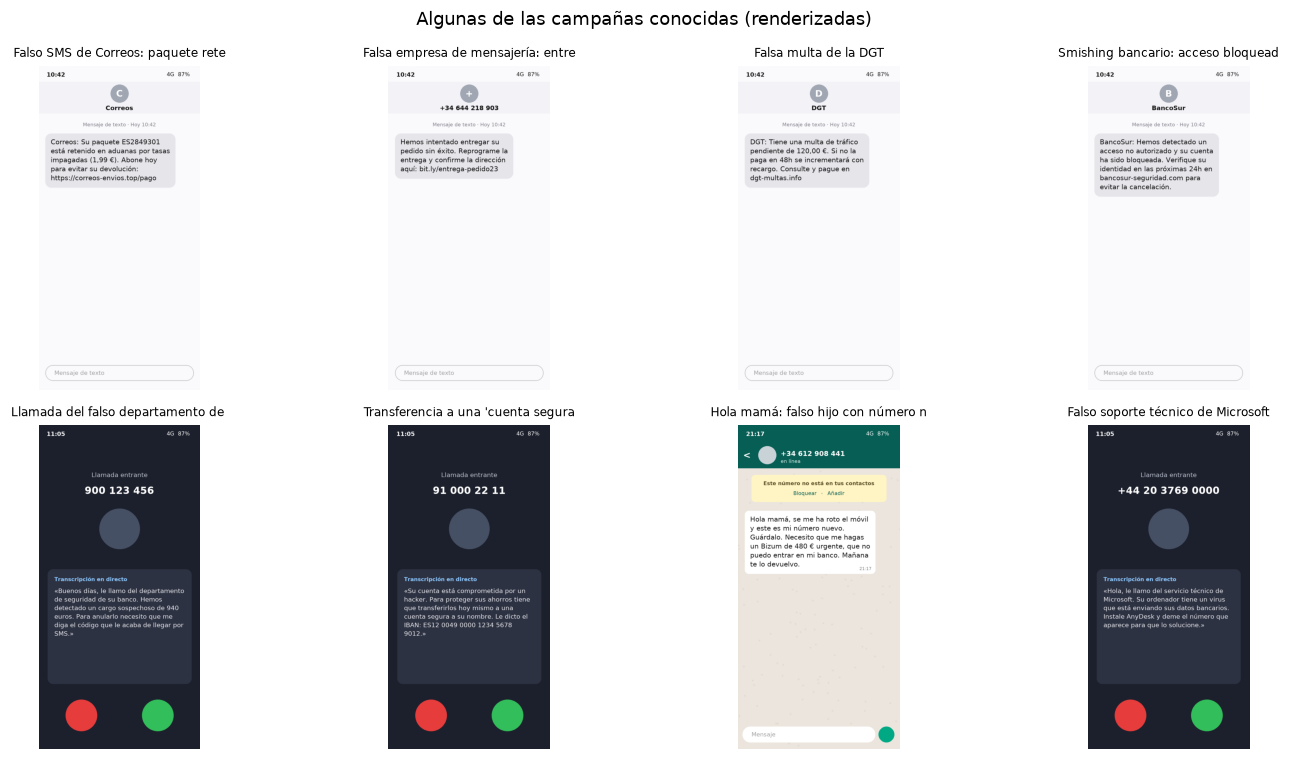

In [13]:
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, c in zip(axes.flat, camps[:8]):
    ax.imshow(Image.open(config.CAMPAIGNS_DIR / "img" / f"{c['id']}.png")); ax.set_title(c["nombre"][:34], fontsize=8); ax.axis("off")
plt.suptitle("Algunas de las campañas conocidas (renderizadas)")
plt.tight_layout()

## 6. Audio: simulación del canal telefónico

**El problema del atajo.** La voz humana de MLS es lectura de audiolibro grabada con micrófono, y la voz
sintética sale «de estudio». Un clasificador entrenado así aprendería a distinguir **calidades de
grabación**, no voces sintéticas, y fallaría en una llamada real. Por eso todo el audio (real y
sintético) pasa por el mismo **canal telefónico simulado** (`src/diputado/data/telephony.py`):

1. remuestreo a 8 kHz (banda estrecha telefónica);
2. filtro paso banda de 300 a 3400 Hz (Butterworth de orden 4);
3. ganancia aleatoria y compresión **mu-law** de 8 bits (G.711);
4. ruido gaussiano con una SNR aleatoria entre 18 y 35 dB.

En el notebook 03 medimos cuánto cambia el resultado con y sin este canal.

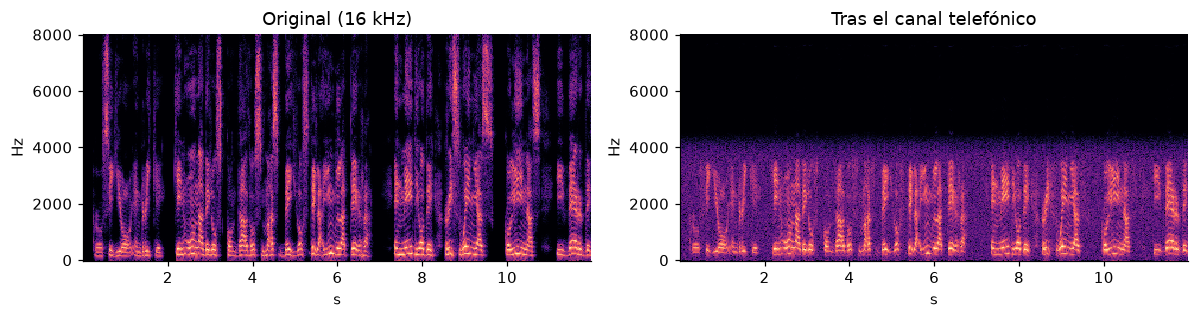

In [14]:
from scipy.signal import spectrogram

from diputado.data import telephony, voices

real = voices.real_clips("dev", n=1, seed=1)
x = voices.load_wav(real["path"][0])
y = telephony.phone_channel(x, voices.SR, np.random.default_rng(0), out_sr=voices.SR)
fig, axes = plt.subplots(1, 2, figsize=(11, 3))
for ax, sig, title in [(axes[0], x, "Original (16 kHz)"), (axes[1], y, "Tras el canal telefónico")]:
    f, t, Sxx = spectrogram(sig, voices.SR, nperseg=512)
    ax.pcolormesh(t, f, 10 * np.log10(Sxx + 1e-10), shading="auto", cmap="magma")
    ax.set_title(title); ax.set_ylabel("Hz"); ax.set_xlabel("s")
plt.tight_layout()
display(Audio(x, rate=voices.SR), Audio(y, rate=voices.SR))

### La llamada del falso banco (caso 1 de la demo)

Generamos con Bark (`v2/es_speaker_8`) el guion de un falso empleado de seguridad que pide el código SMS,
y lo pasamos por el canal telefónico. Bark genera habla con prosodia natural, pausas y respiraciones,
lo que la hace más verosímil que un TTS clásico; es exactamente el tipo de voz que preocupa a los bancos.

In [15]:
print(demo_cases.CALL_SCRIPT)
call = config.DEMO_DIR / "llamada_falso_banco.wav"
if not call.exists():
    demo_cases.build_call()
display(Audio(str(call)))

Buenos días, le llamo del departamento de seguridad de BancoSur. Hemos detectado un cargo de novecientos cuarenta euros en su tarjeta. Para anularlo necesito que me diga ahora mismo el código de seis cifras que le acaba de llegar por SMS. Es muy urgente, si no lo cancelamos en cinco minutos el dinero se perderá.


## 7. Dataset de voz real frente a sintética

* **Voz humana:** Multilingual LibriSpeech en español. Usamos el split `1_hours` para entrenar y `dev`
  para evaluar, que tienen **locutores distintos**: así medimos generalización a voces no vistas.
* **Voz sintética:** dos generadores con arquitecturas muy distintas, **MMS-TTS** (VITS, Meta) y
  **Bark** (transformer de tokens de audio, Suno). Tener dos permite la validación *dejando fuera un
  generador* del notebook 03: entrenar con uno y evaluar con el otro.
* **Texto de los clips sintéticos:** mitad transcripciones de MLS (mismo contenido que la voz real) y
  mitad mensajes de estafa del dataset sintético, para que el **tema** no sea un atajo.
* Para cada clip guardamos dos embeddings CLAP (512 dimensiones): el del audio original y el del audio
  tras el canal telefónico.

In [16]:
manifest = voices.build_dataset()
emb = voices.build_embeddings(manifest)
display(manifest.groupby(["generador", "split_origen"]).agg(clips=("path", "size"), duracion_media_s=("duracion_s", "mean"),
                                                         locutores=("locutor", "nunique")).round(1))

clips  duracion_media_s  locutores
generador split_origen                                    
bark      sintetico        80               9.5         10
humano    1_hours         160               8.0         22
          dev             120               8.0         20
mms       sintetico       160               9.9          1

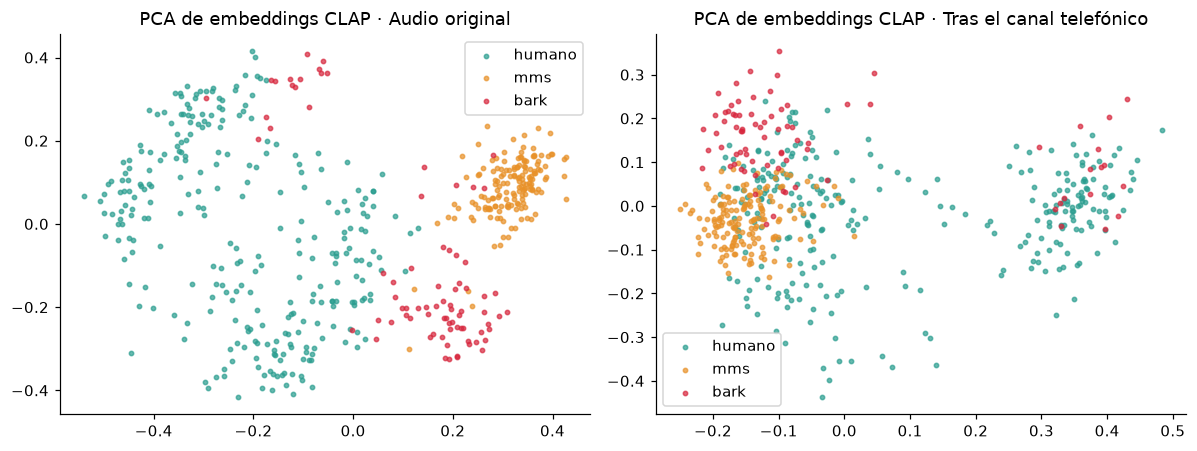

In [17]:
from sklearn.decomposition import PCA

colors = {"humano": "#2a9d8f", "mms": "#e89128", "bark": "#d7263d"}
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, key, title in [(axes[0], "limpio", "Audio original"), (axes[1], "telefono", "Tras el canal telefónico")]:
    Z = PCA(2, random_state=0).fit_transform(emb[key])
    for g, col in colors.items():
        m = (manifest["generador"] == g).values
        ax.scatter(Z[m, 0], Z[m, 1], s=8, c=col, label=g, alpha=0.7)
    ax.set_title(f"PCA de embeddings CLAP · {title}"); ax.legend()
plt.tight_layout()

**Lectura.** Con el audio original los tres grupos están muy separados: un clasificador trivial
acertaría, pero en parte por la calidad de grabación. Tras el canal telefónico los grupos se acercan y la
tarea se vuelve más realista (y más difícil). Entrenaremos y evaluaremos con la versión telefónica.

In [18]:
i_h = manifest.index[manifest["generador"] == "humano"][0]
i_m = manifest.index[manifest["generador"] == "mms"][0]
i_b = manifest.index[manifest["generador"] == "bark"][0]
for i in (i_h, i_m, i_b):
    display(Markdown(f"**{manifest.loc[i, 'generador']}** · {manifest.loc[i, 'texto'][:90]}…"))
    display(Audio(str(ROOT / manifest.loc[i, "path"])))

**humano** · estcá uno dispuesto para la marcha dijo pello he concluido las despedidas qué te han dicho…

**mms** · ¿Quieres un trabajo desde casa con salario de 1.800€? Para confirmar, debes hacer un depós…

**bark** · ¿Quieres un trabajo desde casa con salario de 1.800€? Para confirmar, debes hacer un depós…

## 8. Fichas de los datos

| | Textos sintéticos | Test manual | Voz |
|---|---|---|---|
| **Autoría** | Generados por nosotros con Qwen3 8B a partir de recetas | Escritos a mano por nosotros | MLS (CC BY 4.0) + Bark y MMS generados por nosotros |
| **Idioma** | Español de España | Español de España | Español |
| **Etiquetas** | Estafa + 7 tácticas, heredadas de la receta | Estafa + 7 tácticas, manuales | Humano / sintético + generador |
| **Datos personales** | Ninguno (nombres e IBAN inventados) | Ninguno | Locutores de audiolibros públicos |
| **Sesgos conocidos** | Estilo homogéneo del LLM; recetas limitadas a campañas conocidas | Tamaño pequeño (61) | Lectura de audiolibro, no conversación; solo dos sintetizadores |
| **Uso previsto** | Entrenar TacticNet | Evaluar generalización | Entrenar y evaluar VozSinteticaNet |
| **Uso no previsto** | Generar mensajes de estafa para uso real | | Identificar locutores |

**Nota ética.** Generar ejemplos de estafas es un uso dual. Lo mitigamos con nombres de empresas
inventados, sin enlaces funcionales y con el único propósito de entrenar un detector.

In [19]:
print("Ficheros generados:")
for p in [CSV, emb_dir / "synth_e5.npy", voices.MANIFEST, voices.EMBEDDINGS, call, demo_cases.DEMO_JSON]:
    print(f"  {p.relative_to(ROOT)}  ({p.stat().st_size / 1024:.0f} KB)")

Ficheros generados:
  data\synthetic\textos_sinteticos.csv  (190 KB)
  data\synthetic\embeddings\synth_e5.npy  (1548 KB)
  data\synthetic\voz_manifest.csv  (117 KB)
  data\synthetic\voz_clap.npz  (1928 KB)
  data\demo\llamada_falso_banco.wav  (796 KB)
  data\demo\demo_cases.json  (1 KB)
